<a href="https://colab.research.google.com/github/anujithesh26-del/SIH-2026-AI-ML-ENABLED-SEAMLESS-NAVIGATION/blob/testing/SIH_Vehicle_dead_reckoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload a vehicle-ECU IO-VNBD CSV file (V-*.csv).


Saving V-S3a.csv to V-S3a (1).csv
Uploaded file: V-S3a (1).csv

Window: 100s to 150s (50s duration)
Final position error vs GPS ground truth: 50.6 meters


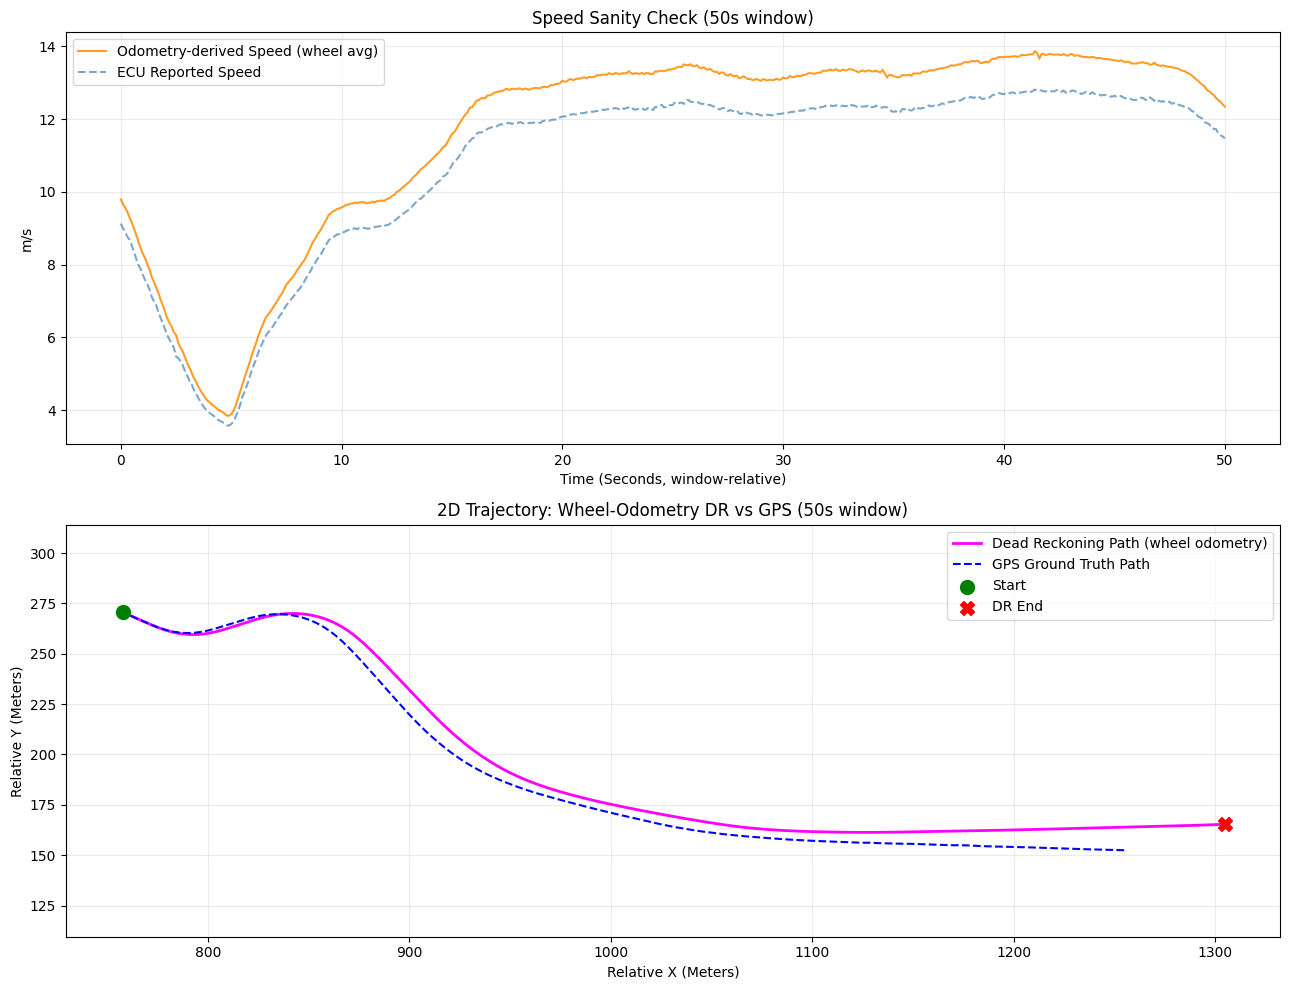


Error vs simulated outage duration (starting at t=100s):
    30s outage -> 26.8 m error
    60s outage -> 62.0 m error
    90s outage -> 96.4 m error
   120s outage -> 109.5 m error


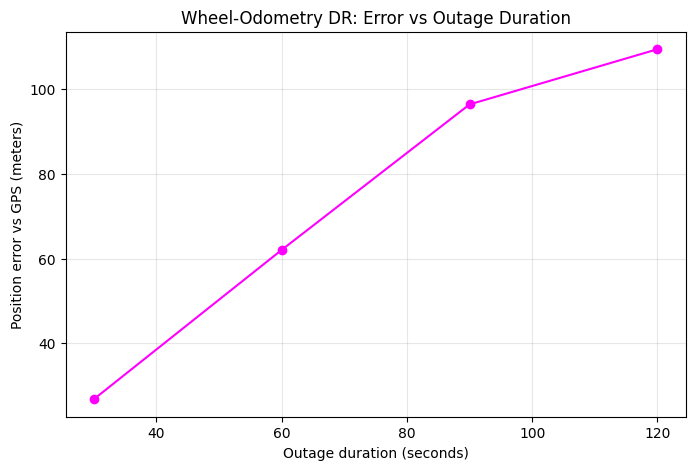

In [ ]:
import io
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import clear_output

clear_output(wait=True)

# -------------------------------------------------------------
# 0. CONFIG -- set your analysis window here (keep in sync with the
# phone-only script's window if you want a fair side-by-side comparison)
# -------------------------------------------------------------
WINDOW_START_S = 100
WINDOW_END_S = 150
DURATIONS_TO_TEST_S = [30, 60, 90, 120]

# Wheel radius assumption -- tune this using the speed sanity-check
# plot (odom_speed_mps vs ecu_speed_mps) until the two lines roughly
# track each other before trusting distance numbers.
WHEEL_RADIUS_M = 0.30

# -------------------------------------------------------------
# 1. FILE UPLOAD
# -------------------------------------------------------------
print("Please upload a vehicle-ECU IO-VNBD CSV file (V-*.csv).")
uploaded = files.upload()

if uploaded:
    filename = next(iter(uploaded))
    print(f"Uploaded file: {filename}\n")
else:
    print("Error: No file uploaded. Please re-run the cell and select a file.")
    sys.exit()

# -------------------------------------------------------------
# 2. DATA LOADING & COLUMN MAPPING (vehicle-ECU file only)
# -------------------------------------------------------------
def load_vehicle_data(file_buffer):
    df = pd.read_csv(io.BytesIO(file_buffer), encoding='latin1')
    df.columns = df.columns.str.strip()

    column_mapping = {
        'Time Since Start of Day (seconds)': 'time_s',
        'Latitude (degrees)': 'lat',
        'Longitude (degrees)': 'lon',
        'Indicated Vehicle Speed (km/hr)': 'ecu_speed_kmh',
        'Yaw Rate (deg/sec)': 'yaw_rate_deg',
        'Wheel Speed Front Left (rad/sec)': 'wheel_fl',
        'Wheel Speed Front Right (rad/sec)': 'wheel_fr',
        'Wheel Speed Rear Left (rad/sec)': 'wheel_rl',
        'Wheel Speed Rear Right (rad/sec)': 'wheel_rr',
        'Steering Angle (degrees)': 'steering_angle',
    }

    missing = [k for k in column_mapping if k not in df.columns]
    if missing:
        print("WARNING: this doesn't look like a vehicle-ECU file. Missing columns:")
        for m in missing:
            print(" -", m)
        print("Use dead_reckoning_fixed.py instead for phone-side S-*.csv files.")

    df.rename(columns=column_mapping, inplace=True)
    return df

df = load_vehicle_data(uploaded[filename])

# -------------------------------------------------------------
# 3. FULL-RECORDING PREP
# -------------------------------------------------------------
df['t_sec'] = pd.to_numeric(df['time_s'], errors='coerce')
df['t_sec'] = df['t_sec'] - df['t_sec'].iloc[0]

df['wheel_speed_avg_rad_s'] = df[['wheel_fl', 'wheel_fr', 'wheel_rl', 'wheel_rr']].mean(axis=1)
df['odom_speed_mps'] = df['wheel_speed_avg_rad_s'] * WHEEL_RADIUS_M
df['ecu_speed_mps'] = df['ecu_speed_kmh'] / 3.6
df['yaw_rate_rad_s'] = np.radians(df['yaw_rate_deg'])

R = 6371000
lat0, lon0 = np.radians(df['lat'].iloc[0]), np.radians(df['lon'].iloc[0])
df['gps_x'] = R * (np.radians(df['lon']) - lon0) * np.cos(lat0)
df['gps_y'] = R * (np.radians(df['lat']) - lat0)


def run_dr_over_window(df, start_s, end_s):
    """Run wheel-odometry dead reckoning from start_s to end_s,
    re-zeroed at the window start, heading aligned to GPS bearing."""
    window = df[(df['t_sec'] >= start_s) & (df['t_sec'] <= end_s)].copy()
    if len(window) < 3:
        return None

    window = window.reset_index(drop=True)
    window['t_rel'] = window['t_sec'] - window['t_sec'].iloc[0]
    window['dt'] = window['t_rel'].diff().fillna(0.1)

    # FIX: align initial heading to GPS bearing at window start,
    # instead of assuming the vehicle starts pointing along +X.
    gx0, gy0 = window['gps_x'].iloc[0], window['gps_y'].iloc[0]
    gx1, gy1 = window['gps_x'].iloc[min(3, len(window) - 1)], window['gps_y'].iloc[min(3, len(window) - 1)]
    initial_heading = np.arctan2(gy1 - gy0, gx1 - gx0)

    window['heading_rad'] = initial_heading + (window['yaw_rate_rad_s'] * window['dt']).cumsum()
    window['delta_x'] = window['odom_speed_mps'] * np.cos(window['heading_rad']) * window['dt']
    window['delta_y'] = window['odom_speed_mps'] * np.sin(window['heading_rad']) * window['dt']
    window['dr_x'] = gx0 + window['delta_x'].cumsum()
    window['dr_y'] = gy0 + window['delta_y'].cumsum()

    error_m = np.sqrt(
        (window['dr_x'].iloc[-1] - window['gps_x'].iloc[-1]) ** 2
        + (window['dr_y'].iloc[-1] - window['gps_y'].iloc[-1]) ** 2
    )
    return window, error_m


# -------------------------------------------------------------
# 4. MAIN WINDOW
# -------------------------------------------------------------
result = run_dr_over_window(df, WINDOW_START_S, WINDOW_END_S)
if result is None:
    print("Window too short or out of range -- adjust WINDOW_START_S / WINDOW_END_S.")
    sys.exit()
window, main_error_m = result

print(f"Window: {WINDOW_START_S}s to {WINDOW_END_S}s ({WINDOW_END_S - WINDOW_START_S}s duration)")
print(f"Final position error vs GPS ground truth: {main_error_m:.1f} meters")

# -------------------------------------------------------------
# 5. VISUALIZATION (main window)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

axes[0].plot(window['t_rel'], window['odom_speed_mps'], label='Odometry-derived Speed (wheel avg)', color='darkorange', alpha=0.85)
axes[0].plot(window['t_rel'], window['ecu_speed_mps'], label='ECU Reported Speed', color='steelblue', alpha=0.7, linestyle='--')
axes[0].set_title(f'Speed Sanity Check ({WINDOW_END_S - WINDOW_START_S}s window)')
axes[0].set_ylabel('m/s')
axes[0].set_xlabel('Time (Seconds, window-relative)')
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].plot(window['dr_x'], window['dr_y'], label='Dead Reckoning Path (wheel odometry)', color='magenta', linewidth=2)
axes[1].plot(window['gps_x'], window['gps_y'], label='GPS Ground Truth Path', color='blue', linestyle='--', linewidth=1.5)
axes[1].scatter(window['dr_x'].iloc[0], window['dr_y'].iloc[0], color='green', marker='o', s=100, label='Start', zorder=5)
axes[1].scatter(window['dr_x'].iloc[-1], window['dr_y'].iloc[-1], color='red', marker='X', s=100, label='DR End', zorder=5)
axes[1].set_title(f'2D Trajectory: Wheel-Odometry DR vs GPS ({WINDOW_END_S - WINDOW_START_S}s window)')
axes[1].set_xlabel('Relative X (Meters)')
axes[1].set_ylabel('Relative Y (Meters)')
axes[1].axis('equal')
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 6. ERROR VS OUTAGE DURATION
# -------------------------------------------------------------
durations_results = []
for dur in DURATIONS_TO_TEST_S:
    r = run_dr_over_window(df, WINDOW_START_S, WINDOW_START_S + dur)
    if r is not None:
        durations_results.append((dur, r[1]))

print("\nError vs simulated outage duration (starting at t=%ds):" % WINDOW_START_S)
for dur, err in durations_results:
    print(f"  {dur:>4}s outage -> {err:.1f} m error")

if durations_results:
    plt.figure(figsize=(8, 5))
    plt.plot([d for d, _ in durations_results], [e for _, e in durations_results], marker='o', color='magenta')
    plt.title('Wheel-Odometry DR: Error vs Outage Duration')
    plt.xlabel('Outage duration (seconds)')
    plt.ylabel('Position error vs GPS (meters)')
    plt.grid(alpha=0.3)
    plt.show()